# Intern Feedback Sentiment Analysis — Beginner Friendly


In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## Load the dataset



In [2]:
df = pd.read_csv("intern_feedback_sentiment_data.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1000, 4)


,intern_id,feedback,satisfaction_rating,sentiment
0,INT-0001,The training was insufficient and I needed mor...,1,Negative
1,INT-0002,I was unhappy with the lack of communication. ...,1,Negative
2,INT-0003,The learning opportunities were reasonable. Ov...,3,Neutral
3,INT-0004,I felt unsupported during most of the internship.,1,Negative
4,INT-0005,I received good guidance and felt confident co...,4,Positive


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment counts:")
print(df["sentiment"].value_counts())


Column names:
['intern_id', 'feedback', 'satisfaction_rating', 'sentiment']

Missing values:
intern_id              0
feedback               0
satisfaction_rating    0
sentiment              0
dtype: int64

Sentiment counts:
sentiment
Positive    428
Negative    355
Neutral     217
Name: count, dtype: int64


## Visualize the sentiment distribution



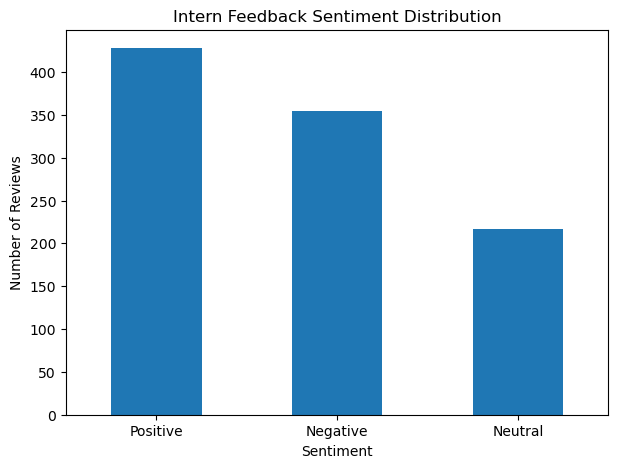

In [4]:
df["sentiment"].value_counts().plot(kind="bar", figsize=(7, 5))
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Intern Feedback Sentiment Distribution")
plt.xticks(rotation=0)
plt.show()


## Select input and target



In [5]:
X = df["feedback"]
y = df["sentiment"]

print("Input examples:")
print(X.head())

print("\nTarget examples:")
print(y.head())


Input examples:
0    The training was insufficient and I needed mor...
1    I was unhappy with the lack of communication. ...
2    The learning opportunities were reasonable. Ov...
3    I felt unsupported during most of the internship.
4    I received good guidance and felt confident co...
Name: feedback, dtype: object

Target examples:
0    Negative
1    Negative
2     Neutral
3    Negative
4    Positive
Name: sentiment, dtype: object


## Split data into training and testing sets


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 800
Testing samples: 200


## Build the Logistic Regression model



In [7]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")


Logistic Regression model trained successfully!


## Make predictions


In [8]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])


First 10 predictions:
['Positive' 'Positive' 'Positive' 'Positive' 'Neutral' 'Neutral'
 'Positive' 'Positive' 'Negative' 'Negative']


## Evaluate the model


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        71
     Neutral       1.00      1.00      1.00        43
    Positive       1.00      1.00      1.00        86

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Confusion Matrix


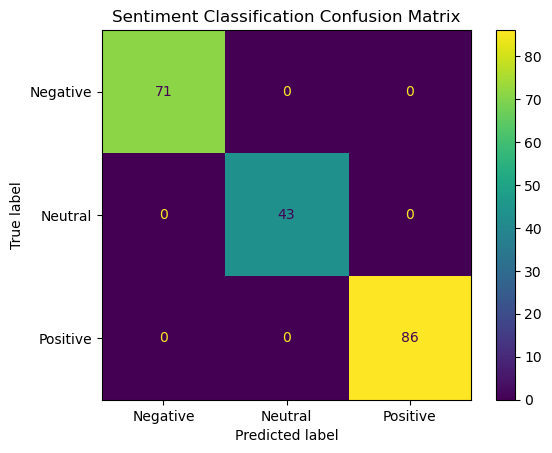

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=["Negative", "Neutral", "Positive"])

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

display_cm.plot()
plt.title("Sentiment Classification Confusion Matrix")
plt.show()


## Test the model with new feedback



In [11]:
new_feedback = [
    "My mentor was excellent and helped me learn many new skills.",
    "The communication was poor and I felt unsupported.",
    "The internship was okay and the workload was manageable."
]

predictions = model.predict(new_feedback)
probabilities = model.predict_proba(new_feedback).max(axis=1)

for text, prediction, probability in zip(new_feedback, predictions, probabilities):
    print("Feedback:", text)
    print("Predicted sentiment:", prediction)
    print("Confidence:", round(probability * 100, 2), "%")
    print("-" * 70)


Feedback: My mentor was excellent and helped me learn many new skills.
Predicted sentiment: Positive
Confidence: 79.95 %
----------------------------------------------------------------------
Feedback: The communication was poor and I felt unsupported.
Predicted sentiment: Negative
Confidence: 95.21 %
----------------------------------------------------------------------
Feedback: The internship was okay and the workload was manageable.
Predicted sentiment: Neutral
Confidence: 78.78 %
----------------------------------------------------------------------


## 12. Find common words in negative feedback
**.


In [12]:
negative_feedback = df[df["sentiment"] == "Negative"]["feedback"]

negative_words = (
    negative_feedback
    .str.lower()
    .str.replace(r"[^a-z\s]", "", regex=True)
    .str.split()
    .explode()
)

stop_words = {
    "the", "and", "was", "were", "i", "my", "to", "a", "of",
    "with", "did", "not", "for", "this", "is", "in", "enough",
    "more", "very", "during", "most"
}

common_negative_words = (
    negative_words[~negative_words.isin(stop_words)]
    .value_counts()
    .head(15)
)

print(common_negative_words)


feedback
would            193
internship       169
be               124
like             108
regular           77
meetings          77
helpful           77
experience        65
overall           65
recommend         62
about             60
communication     58
opportunities     54
improved          47
can               47
Name: count, dtype: int64


In [13]:
def find_area(text):
    text = text.lower()

    if any(word in text for word in ["mentor", "guidance", "support"]):
        return "Mentoring / Guidance"
    elif any(word in text for word in ["communication", "communicate", "meetings"]):
        return "Communication"
    elif any(word in text for word in ["training", "trained"]):
        return "Training"
    elif any(word in text for word in ["workload", "schedule", "stressful"]):
        return "Workload / Scheduling"
    elif any(word in text for word in ["task", "tasks", "responsibilities", "deadlines"]):
        return "Task Clarity"
    elif any(word in text for word in ["learning", "skills", "practical"]):
        return "Learning Opportunities"
    else:
        return "Other"

negative_df = df[df["sentiment"] == "Negative"].copy()
negative_df["improvement_area"] = negative_df["feedback"].apply(find_area)

area_counts = negative_df["improvement_area"].value_counts()

print("Areas mentioned in negative feedback:")
print(area_counts)


Areas mentioned in negative feedback:
improvement_area
Communication             111
Mentoring / Guidance       72
Learning Opportunities     49
Other                      44
Task Clarity               42
Training                   20
Workload / Scheduling      17
Name: count, dtype: int64


## Visualize areas for improvement


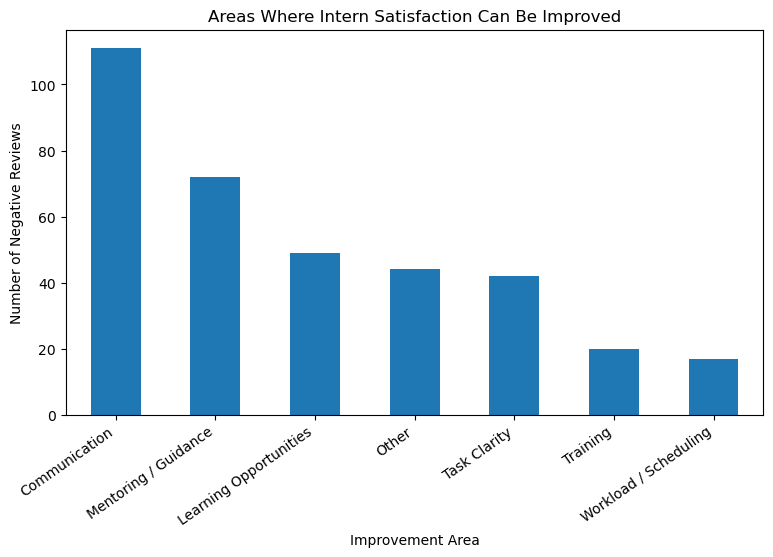

In [14]:
area_counts.plot(kind="bar", figsize=(9, 5))
plt.xlabel("Improvement Area")
plt.ylabel("Number of Negative Reviews")
plt.title("Areas Where Intern Satisfaction Can Be Improved")
plt.xticks(rotation=35, ha="right")
plt.show()


## Create an improvement report


In [15]:
improvement_report = pd.DataFrame({
    "Improvement Area": area_counts.index,
    "Negative Feedback Count": area_counts.values
})

improvement_report["Percentage of Negative Feedback"] = (
    improvement_report["Negative Feedback Count"]
    / len(negative_df) * 100
).round(2)

improvement_report


,Improvement Area,Negative Feedback Count,Percentage of Negative Feedback
0,Communication,111,31.27
1,Mentoring / Guidance,72,20.28
2,Learning Opportunities,49,13.80
3,Other,44,12.39
4,Task Clarity,42,11.83
5,Training,20,5.63
6,Workload / Scheduling,17,4.79


## Save the results


In [16]:
test_results = pd.DataFrame({
    "Feedback": X_test.values,
    "Actual_Sentiment": y_test.values,
    "Predicted_Sentiment": y_pred
})

with pd.ExcelWriter("intern_feedback_analysis.xlsx", engine="openpyxl") as writer:
    test_results.to_excel(writer, sheet_name="Predictions", index=False)
    improvement_report.to_excel(writer, sheet_name="Improvement Areas", index=False)

print("Saved: intern_feedback_analysis.xlsx")


Saved: intern_feedback_analysis.xlsx
